## Packages

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## Dataset

### Load

In [82]:
X = np.load("data/X.npy")
y = np.load("data/y.npy")

X = X[0:1000]
y = y[0:1000]

### View the variables

In [83]:
print(f"First element of X is: {X[0]}")

First element of X is: [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  

In [84]:
print(f"The first element of y is: {y[0,0]}")
print(f"The last element of y is: {y[-1,0]}")

The first element of y is: 0
The last element of y is: 1


### Dimension of variables

In [85]:
print(f"Shape of X is: {X.shape}")
print(f"Shape of y is: {y.shape}")

Shape of X is: (1000, 400)
Shape of y is: (1000, 1)


### Visualizing the data

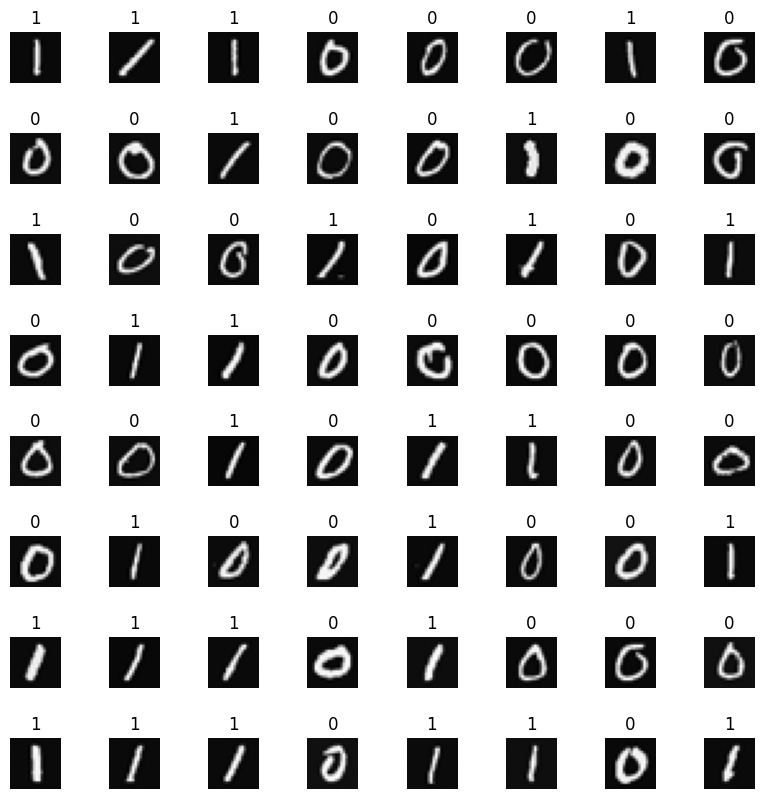

In [86]:
m,n = X.shape

fig,axes = plt.subplots(8,8,figsize=(8,8))

# pad controls the outer edge, h_pad controls the vertical space between rows
fig.tight_layout(pad=0.5, h_pad=1.5)

for i,ax in enumerate(axes.flat):
    # select random indices
    random_index=np.random.randint(m)

    # Select the row corresponding random index
    # and reshape the imgae
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label of the image
    ax.set_title(y[random_index, 0])

    ax.set_axis_off()
plt.show()

## Models

### Tensorflow model implementation
- Keras Sequential model
- Dense Layer
- Sigmoid activation

In [87]:
model = Sequential(
    [
        tf.keras.Input(shape=(400,)),

        tf.keras.layers.Dense(units=25, activation='sigmoid', name="layer1"),
        tf.keras.layers.Dense(units=15, activation='sigmoid', name="layer2"),
        tf.keras.layers.Dense(units=1, activation='sigmoid', name="layer3"),
    ],
    name="my_model"
)

#### Model summary

In [88]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Extract params

In [89]:
[layer1, layer2, layer3]=model.layers

W1,b1=layer1.get_weights()
W2,b2=layer2.get_weights()
W3,b3=layer3.get_weights()

print(f"w1 shape: {W1.shape}, b1 shape: {b1.shape}")
print(f"w1 shape: {W2.shape}, b1 shape: {b2.shape}")
print(f"w1 shape: {W3.shape}, b1 shape: {b3.shape}")

w1 shape: (400, 25), b1 shape: (25,)
w1 shape: (25, 15), b1 shape: (15,)
w1 shape: (15, 1), b1 shape: (1,)


In [90]:
print(W3)

[[-0.4146803 ]
 [ 0.12932956]
 [-0.2083095 ]
 [ 0.05570215]
 [ 0.6000859 ]
 [ 0.4176926 ]
 [-0.02270216]
 [ 0.3256911 ]
 [ 0.09187317]
 [ 0.1416865 ]
 [-0.1277456 ]
 [ 0.14158899]
 [-0.40476698]
 [ 0.56639487]
 [ 0.60504645]]


#### Manual params count

In [91]:
m1,n1 = W1.shape
m2,n2 = W2.shape
m3,n3 = W3.shape

layer1_params = (m1*n1)+n1
layer2_params = (m2*n2)+n2
layer3_params = (m3*n3)+n3
print(f"Layer 1: {layer1_params}")
print(f"Layer 2: {layer2_params}")
print(f"Layer 3: {layer3_params}")
print(f"Total: {layer1_params+layer2_params+layer3_params}")

Layer 1: 10025
Layer 2: 390
Layer 3: 16
Total: 10431


#### Compile and fit
The following code will define a loss function and run gradient descent to fit the weights of the model to the training data. This will be explained in more detail in the following week.

In [92]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001)
)

model.fit(
    X,y,
    epochs=20
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6543
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5103
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3774
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2716 
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2017 
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1563 
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1259
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1046
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0889 
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0768 
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0674 
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0599
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0538 
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0486 
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0444 
Epoch 16/2

#### Predict

In [93]:
prediction=model.predict(X[0].reshape(1,400)) #0
print(f"Predicting a zero: {prediction}")

prediction=model.predict(X[500].reshape(1,400)) #1
print(f"Predicting a one: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicting a zero: [[0.03664875]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicting a one: [[0.9884823]]


#### Compare predictions vs label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

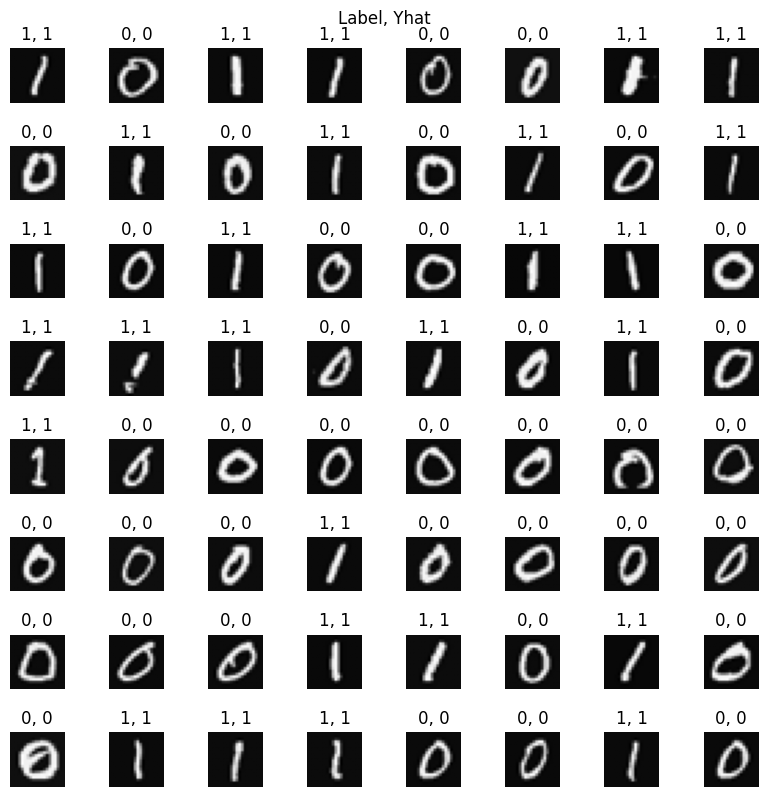

In [94]:
m,n=X.shape

fig,axes=plt.subplots(8,8,figsize=(8,8))

for i,ax in enumerate(axes.flat):

    random_index=np.random.randint(m)

    X_rand_reshaped=X[random_index].reshape((20,20)).T
    # display the image
    ax.imshow(X_rand_reshaped, cmap='gray')
    # predic
    prediction=model.predict(X[random_index].reshape(1,400))
    if(prediction>=0.5):
        yhat=1
    else:
        yhat=0

    ax.set_title(f"{y[random_index,0]}, {yhat}")
    ax.set_axis_off()

fig.suptitle(f"Label, Yhat")
fig.tight_layout(pad=0.5,h_pad=1.5)
plt.show()


### NumPy model implementation : Forward propagation in NumPy

#### Activation function definition

In [95]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

#### Dense layer definition

In [96]:
def myDense(a_in, W, b, g):
    
    print(f"Input shape: {a_in.shape}")
    # num of units/neurons
    units=W.shape[1]
    print(f"Number of units: {units}")
    # Define output shape
    a_out=np.zeros(units)
    print(f"Output shape: {a_out.shape}")

    for i in range(units):
        w=W[:,i]
        z=np.dot(a_in,w)+b[i]
        a_out[i]=g(z);
        print(f"Neuron: {i}, W Shape: {w.shape}, b: {b[i]}, z: {z}, a_out: {a_out[i]}")
    
    print("__________layer operation completed__________")
    return(a_out)


#### Model definition

In [97]:
def mySequential(x,W1,b1,W2,b2,W3,b3):
    a1=myDense(x,W1,b1,sigmoid)
    a2=myDense(a1,W2,b2,sigmoid)
    a3=myDense(a2,W3,b3,sigmoid)
    return(a3)

#### Set params

In [98]:
W1_tmp,b1_tmp=layer1.get_weights()
W2_tmp,b2_tmp=layer2.get_weights()
W3_tmp,b3_tmp=layer3.get_weights()

#### Make predictions

In [99]:
prediction=mySequential(
    X[0],
    W1_tmp,b1_tmp,
    W2_tmp,b2_tmp,
    W3_tmp,b3_tmp
)
if(prediction>=0.5):
    yhat=1
else:
    yhat=0
print(f"Neural Network output: {prediction}, Shape: {prediction.shape}")
print(f"Yhat: {yhat}, label: {y[0,0]}")
print(f"#############################")

prediction=mySequential(
    X[500],
    W1_tmp,b1_tmp,
    W2_tmp,b2_tmp,
    W3_tmp,b3_tmp
)
if(prediction>=0.5):
    yhat=1
else:
    yhat=0
print(f"Neural Network output: {prediction}, Shape: {prediction.shape}")
print(f"Yhat: {yhat}, label: {y[500,0]}")
print(f"#############################")


Input shape: (400,)
Number of units: 25
Output shape: (25,)
Neuron: 0, W Shape: (400,), b: -0.14293989539146423, z: 2.7983290508813097, a_out: 0.9425854623423492
Neuron: 1, W Shape: (400,), b: -0.15243539214134216, z: 3.571795265227805, a_out: 0.9726629651798868
Neuron: 2, W Shape: (400,), b: 0.18315845727920532, z: -4.1836746586642946, a_out: 0.015013551469830098
Neuron: 3, W Shape: (400,), b: 0.22072766721248627, z: -4.751185108114848, a_out: 0.008567413225514499
Neuron: 4, W Shape: (400,), b: -0.15480202436447144, z: 2.9606564381919984, a_out: 0.9507647316412124
Neuron: 5, W Shape: (400,), b: 0.13909824192523956, z: -3.2295620305159565, a_out: 0.038068281869687075
Neuron: 6, W Shape: (400,), b: -0.12099311500787735, z: 2.9555825738312884, a_out: 0.9505266742265586
Neuron: 7, W Shape: (400,), b: -0.1383715569972992, z: 2.7179793718821443, a_out: 0.9380792662516416
Neuron: 8, W Shape: (400,), b: -0.16444091498851776, z: 3.169633682873121, a_out: 0.9596754110347141
Neuron: 9, W Shape: 

#### Comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Input shape: (400,)
Number of units: 25
Output shape: (25,)
Neuron: 0, W Shape: (400,), b: -0.14293989539146423, z: -3.1315245663434226, a_out: 0.04182546569401389
Neuron: 1, W Shape: (400,), b: -0.15243539214134216, z: -3.7365030018113172, a_out: 0.023282328368284918
Neuron: 2, W Shape: (400,), b: 0.18315845727920532, z: 4.290577344274531, a_out: 0.9864880581509402
Neuron: 3, W Shape: (400,), b: 0.22072766721248627, z: 4.4495313626355175, a_out: 0.9884508989078732
Neuron: 4, W Shape: (400,), b: -0.15480202436447144, z: -3.4432773232606695, a_out: 0.03096997760944798
Neuron: 5, W Shape: (400,), b: 0.13909824192523956, z: 3.2044683123880877, a_out: 0.9610020818881744
Neuron: 6, W Shape: (400,), b: -0.12099311500787735, z: -2.9328699506635125, a_out: 0.05055239851407608
Neuron: 7, W Shape: (400,), b: -0.1383715569972992, z: -2.918005760147241, a_out: 0.05127061785497609
Neuron: 8, W Shape: (400,), b: -0.16444091498851776, z: -3.2845916609390193, a_ou

C:\Users\User\AppData\Local\Temp\ipykernel_15904\3133046063.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tf_yhat=int(tf_pred>=0.5)
C:\Users\User\AppData\Local\Temp\ipykernel_15904\3133046063.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  my_yhat=int(my_pred>=0.5)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Input shape: (400,)
Number of units: 25
Output shape: (25,)
Neuron: 0, W Shape: (400,), b: -0.14293989539146423, z: -2.1807146899021634, a_out: 0.10149573365176912
Neuron: 1, W Shape: (400,), b: -0.15243539214134216, z: -2.5825007869683665, a_out: 0.07027316666466336
Neuron: 2, W Shape: (400,), b: 0.18315845727920532, z: 2.7464386998452968, a_out: 0.9397119055847728
Neuron: 3, W Shape: (400,), b: 0.22072766721248627, z: 2.9993534422122017, a_out: 0.9525449089526788
Neuron: 4, W Shape: (400,), b: -0.15480202436447144, z: -2.2596580980987557, a_out: 0.09451962679597536
Neuron: 5, W Shape: (400,), b: 0.13909824192523956, z: 2.228545533530572, a_out: 0.9027837821983691
Neuron: 6, W Shape: (400,), b: -0.12099311500787735, z: -2.0763635064652384, a_out: 0.11141547868093954
Neuron: 7, W Shape: (400,), b: -0.1383715569972992, z: -1.6821501149756368, a_out: 0.15681096809085524
Neuron: 8, W Shape: (400,), b: -0.16444091498851776, z: -1.9857187808185937, a_ou

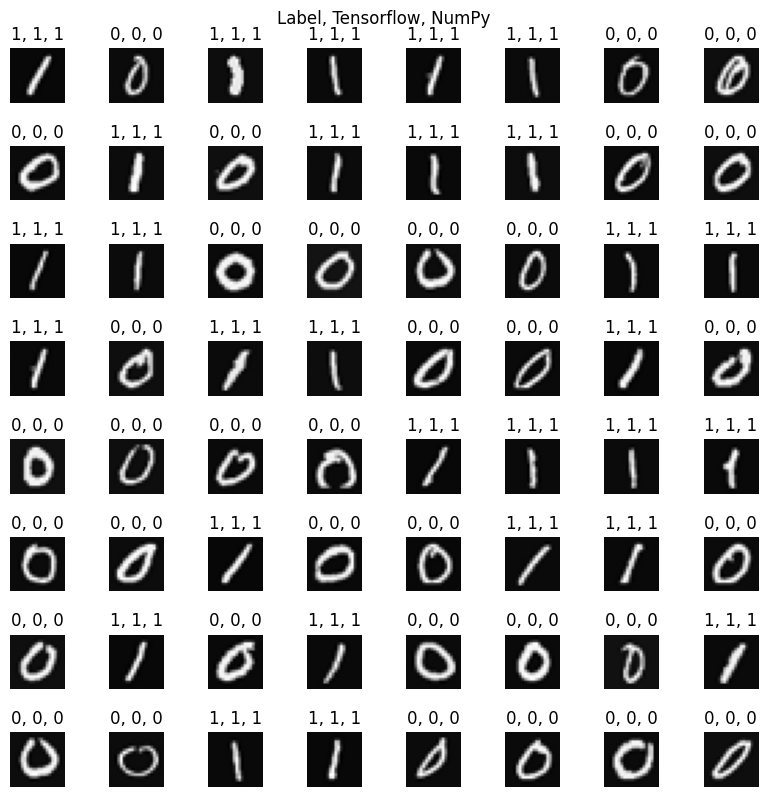

In [100]:
m,n=X.shape

fig,axes=plt.subplots(8,8,figsize=(8,8))

for i,ax in enumerate(axes.flat):

    rand_indx=np.random.randint(m)

    X_random_reshaped=X[rand_indx].reshape((20,20)).T

    ax.imshow(X_random_reshaped, cmap='gray')

    # Predic using tensorflow
    tf_pred=model.predict(X[rand_indx].reshape(1,400))
    tf_yhat=int(tf_pred>=0.5)

    # Predic using numpy forward propagation implementation
    my_pred= mySequential(
        X[rand_indx],
        W1_tmp,b1_tmp,
        W2_tmp,b2_tmp,
        W3_tmp,b3_tmp
    )
    my_yhat=int(my_pred>=0.5)

    ax.set_title(f"{y[rand_indx,0]}, {tf_yhat}, {my_yhat}")
    ax.set_axis_off()

fig.suptitle("Label, Tensorflow, NumPy")
fig.tight_layout(pad=0.5, h_pad=1.5)
plt.show()

### Vectorized NumPy model implementation

We can demonstrate this using the examples `X` and the `W1`,`b1` parameters above. We use `np.matmul` to perform the matrix multiply. Note, the dimensions of x and W must be compatible.

#### Dense layer difinition

In [101]:
def myDense_V(A,W,b,g):
    A_out = g(np.matmul(A,W)+b)
    return (A_out)


#### Model definition

In [102]:
def mySequential_V(X,W1,b1,W2,b2,W3,b3):
    A1=myDense_V(X,W1,b1,sigmoid)
    A2=myDense_V(A1,W2,b2,sigmoid)
    A3=myDense_V(A2,W3,b3,sigmoid)
    return(A3)

#### Make predictions

In [103]:
Prediction = mySequential_V(
    X,
    W1_tmp,
    b1_tmp,
    W2_tmp,
    b2_tmp,
    W3_tmp,
    b3_tmp
)
print(f"Prediction shape: {Prediction.shape}")

Yhat=(Prediction>=0.5).astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

Prediction shape: (1000, 1)
predict a zero:  [0] predict a one:  [1]


#### Compariosn

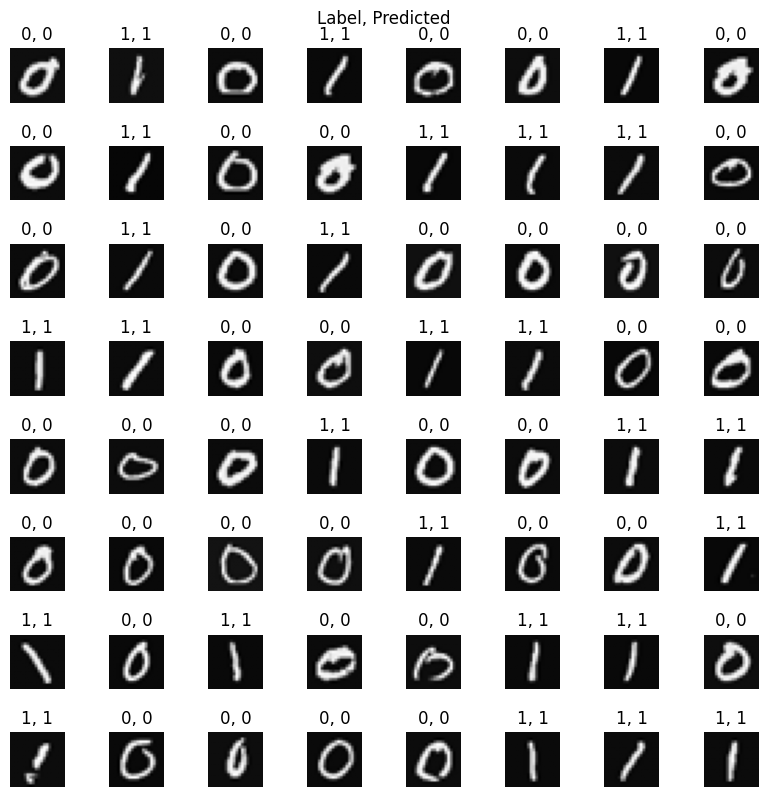

In [104]:
m,n=X.shape

fig,axes=plt.subplots(8,8,figsize=(8,8))

for i,ax in enumerate(axes.flat):

    randomIndex = np.random.randint(m)
    xRandomReshaped=X[randomIndex].reshape((20,20)).T

    ax.imshow(xRandomReshaped, cmap='gray')

    ax.set_title(f"{y[randomIndex,0]}, {Yhat[randomIndex,0]}")

    ax.set_axis_off()

fig.suptitle(f"Label, Predicted")
fig.tight_layout(pad=0.5,h_pad=1.5)
plt.show()

#### Misclassification

Error indices: (array([142]), array([0]))


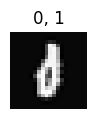

In [105]:
fig=plt.figure(figsize=(1,1))

errors = np.where(y!=Yhat)
print(f"Error indices: {errors}") #It is located at Row 142, Column 0

errorIndex=errors[0][0]
xErrorReshaped=X[errorIndex].reshape((20,20)).T

plt.imshow(xErrorReshaped, cmap='gray')

plt.title(f"{y[errorIndex,0]}, {Yhat[errorIndex, 0]}")
plt.axis('off')
plt.show()